# Les niveaux d'eau de la bonne

In [356]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from functools import reduce
import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler


Récupération des débits instantanés (5 derniers jours)...
✅ 1384 mesures instantanées récupérées.

Récupération des débits moyens journaliers (3 dernières années)...
✅ 1083 mesures journalières récupérées.


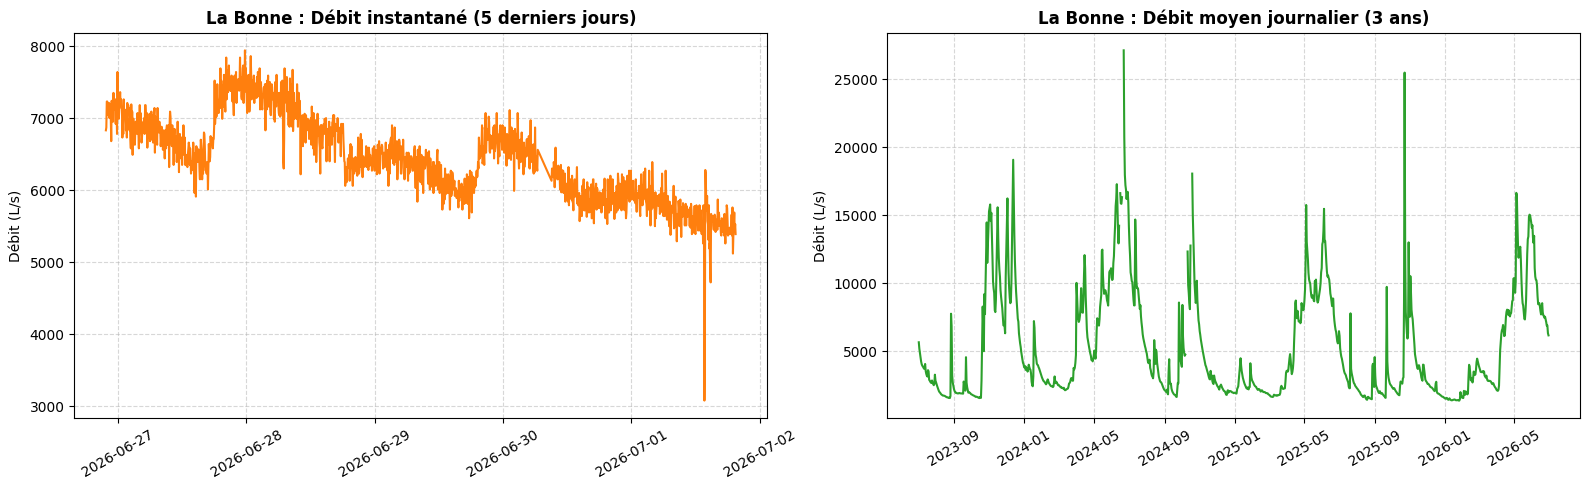

In [163]:
# Configuration
station_code = "W231401001"
now = datetime.now()

# -------------------------------------------------------------------
# 1. DÉBIT INSTANTANÉ (5 DERNIERS JOURS) - Endpoint: observations_tr
# -------------------------------------------------------------------
url_tr = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/observations_tr"
date_5j = (now - timedelta(days=5)).strftime('%Y-%m-%dT%H:%M:%SZ')

params_tr = {
    "code_entite": station_code,
    "grandeur_hydro": "Q",
    "date_fin_obs":  (now).strftime('%Y-%m-%dT%H:%M:%SZ'),
    "date_debut_obs": date_5j,
    "size": 10000,
    "sort": "asc"
}

print("Récupération des débits instantanés (5 derniers jours)...")
resp_tr = requests.get(url_tr, params=params_tr)

if resp_tr.status_code in [200, 206]:
    df_inst = pd.DataFrame(resp_tr.json()['data'])
    df_inst = df_inst[['date_obs', 'resultat_obs']].copy()
    df_inst['date_obs'] = pd.to_datetime(df_inst['date_obs'])
    df_inst['resultat_obs'] = pd.to_numeric(df_inst['resultat_obs'])
    print(f"✅ {len(df_inst)} mesures instantanées récupérées.")
else:
    print(f"❌ Erreur API TR : {resp_tr.status_code}")

# -------------------------------------------------------------------
# 2. DÉBIT MOYEN JOURNALIER QmnJ (3 DERNIÈRES ANNÉES) - Endpoint: obs_elab
# -------------------------------------------------------------------
url_elab = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
date_3ans = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

params_elab = {
    "code_entite": station_code,
    "grandeur_hydro_elab": "QmnJ", 
    "date_debut_obs_elab": date_3ans, # Paramètre corrigé pour la V2
    "size": 2000,                  
    "sort": "asc"
}

print("\nRécupération des débits moyens journaliers (3 dernières années)...")
resp_elab = requests.get(url_elab, params=params_elab)

if resp_elab.status_code in [200, 206]:
    df_moyen = pd.DataFrame(resp_elab.json()['data'])
    
    # CORRECTION : Utilisation des champs spécifiques à l'endpoint obs_elab
    df_moyen = df_moyen[['date_obs_elab', 'resultat_obs_elab']].copy()
    
    # Renommage pour uniformiser tes variables d'analyse
    df_moyen = df_moyen.rename(columns={
        'date_obs_elab': 'date_obs',
        'resultat_obs_elab': 'resultat_obs'
    })
    
    df_moyen['date_obs'] = pd.to_datetime(df_moyen['date_obs'])
    df_moyen['resultat_obs'] = pd.to_numeric(df_moyen['resultat_obs'])
    print(f"✅ {len(df_moyen)} mesures journalières récupérées.")
else:
    print(f"❌ Erreur API Élaborée : {resp_elab.status_code}")
    print(resp_elab.text)

# -------------------------------------------------------------------
# 3. VISUALISATION DES DEUX COURBES
# -------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if 'df_inst' in locals() and not df_inst.empty:
    ax1.plot(df_inst['date_obs'], df_inst['resultat_obs'], color='#ff7f0e')
    ax1.set_title("La Bonne : Débit instantané (5 derniers jours)", fontweight='bold')
    ax1.set_ylabel("Débit (L/s)")
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, linestyle='--', alpha=0.5)

if 'df_moyen' in locals() and not df_moyen.empty:
    ax2.plot(df_moyen['date_obs'], df_moyen['resultat_obs'], color='#2ca02c')
    ax2.set_title("La Bonne : Débit moyen journalier (3 ans)", fontweight='bold')
    ax2.set_ylabel("Débit (L/s)")
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# La météo

Récupération des données météo et neige historiques...
✅ 1096 jours de données météo récupérés.


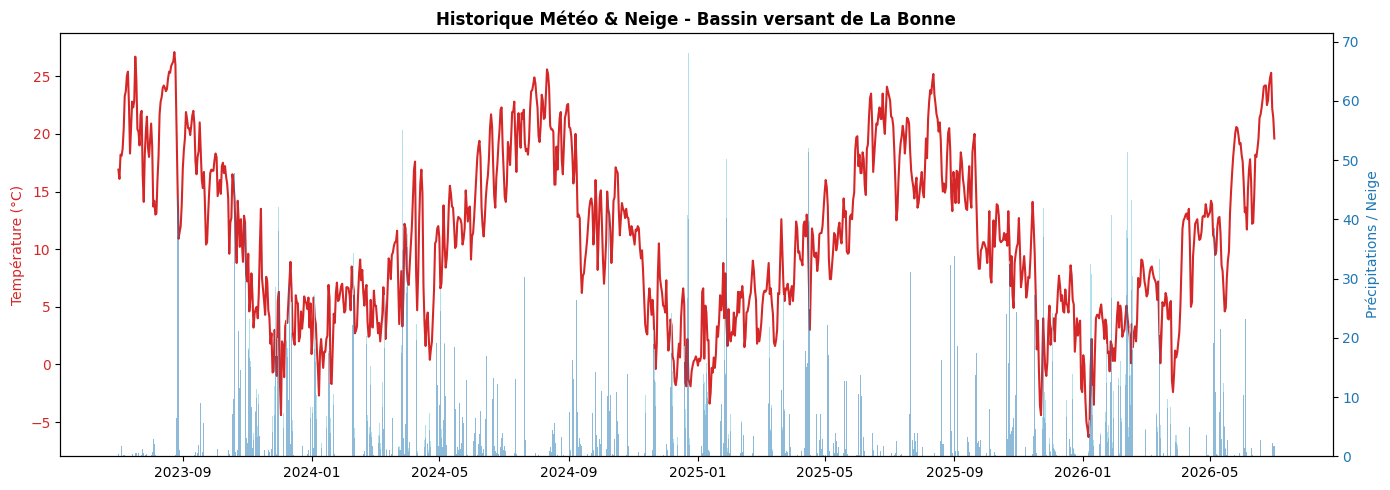

In [164]:
now = datetime.now()
date_fin = now.strftime('%Y-%m-%d')
date_debut = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

# Coordonnées géographiques de la station de La Bonne
lat, lon = 44.9003, 5.9444

# Endpoint de l'API Historique d'Open-Meteo
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": lat,
    "longitude": lon,
    "start_date": date_debut,
    "end_date": date_fin,
    # On demande les cumuls journaliers de pluie, neige et la température moyenne
    "daily": ["temperature_2m_mean", "precipitation_sum", "snowfall_sum"],
    "timezone": "Europe/Paris"
}

print("Récupération des données météo et neige historiques...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    data_meteo = resp_meteo.json()
    
    # Extraction des données journalières
    daily_data = data_meteo['daily']
    
    # Création du DataFrame
    df_meteo = pd.DataFrame({
        'date': pd.to_datetime(daily_data['time']),
        'temperature_moyenne': daily_data['temperature_2m_mean'],
        'precipitations_cumul_mm': daily_data['precipitation_sum'],
        'chute_neige_cumul_cm': daily_data['snowfall_sum'] # Équivalent en eau/neige
    })
    
    print(f"✅ {len(df_meteo)} jours de données météo récupérés.")
    
    # Petit aperçu graphique
    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Courbe des températures
    ax1.plot(df_meteo['date'], df_meteo['temperature_moyenne'], color='#d62728', label='Température moyenne (°C)')
    ax1.set_ylabel('Température (°C)', color='#d62728')
    ax1.tick_params(axis='y', labelcolor='#d62728')

    # Axe secondaire pour les précipitations (pluie + neige)
    ax2 = ax1.twinx()
    ax2.bar(df_meteo['date'], df_meteo['precipitations_cumul_mm'], color='#1f77b4', alpha=0.5, label='Pluie (mm)')
    ax2.bar(df_meteo['date'], df_meteo['chute_neige_cumul_cm'], bottom=df_meteo['precipitations_cumul_mm'], color='#9edae5', alpha=0.8, label='Neige (cm)')
    ax2.set_ylabel('Précipitations / Neige', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    plt.title("Historique Météo & Neige - Bassin versant de La Bonne", fontweight='bold')
    fig.tight_layout()
    plt.show()

else:
    print(f"Erreur API Open-Meteo : {resp_meteo.status_code}")

In [165]:

# 1. Définition du bassin versant (Centre + N, S, E, O)
# Coordonnées géographiques de la station de La Bonne
lat_center, lon_center = 44.9003, 5.9444

# Distance en km pour le quadrillage
distance_km = 30

# Conversion des distances en degrés (approximation)
degree_lat = distance_km / 111  # 1 degré latitude ≈ 111 km
degree_lon = distance_km / (111 * np.cos(np.radians(lat_center)))  # 1 degré longitude ≈ 111 * cos(latitude) km

# Créer le quadrillage
lats = [lat_center - degree_lat, lat_center + degree_lat, lat_center + degree_lat, lat_center - degree_lat, lat_center - degree_lat]
lons = [lon_center - degree_lon, lon_center - degree_lon, lon_center + degree_lon, lon_center + degree_lon, lon_center - degree_lon]


# CORRECTION 1 : Open-Meteo veut une seule chaîne séparée par des virgules
lats_str = ",".join(map(str, lats))
lons_str = ",".join(map(str, lons))

url_meteo = "https://archive-api.open-meteo.com/v1/archive"

# CORRECTION 2 : On bascule tout sur 'hourly'
params_meteo = {
    "latitude": lats_str,
    "longitude": lons_str,
    "start_date": date_3ans, 
    "end_date": date_fin,    
    "hourly": ["temperature_2m", "precipitation", "snow_depth"],
    "timezone": "Europe/Paris"
}

print("Récupération de la météo horaire maillée...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    donnees_points = resp_meteo.json()
    liste_dfs = []
    
    for i, data_point in enumerate(donnees_points):
        # On crée le tableau horaire pour le point i
        df_temp = pd.DataFrame({
            'date': pd.to_datetime(data_point['hourly']['time']),
            f'temp_pt{i}': data_point['hourly']['temperature_2m'],
            f'precip_pt{i}': data_point['hourly']['precipitation'],
            f'neige_sol_pt{i}': data_point['hourly']['snow_depth'] # En mètres !
        })
        
        # CORRECTION 3 : Transformation du pas horaire au pas journalier (Resampling)
        # Moyenne pour la temp, somme pour la pluie, moyenne pour la neige au sol
        df_journalier = df_temp.set_index('date').resample('D').agg({
            f'temp_pt{i}': 'mean',
            f'precip_pt{i}': 'sum',
            f'neige_sol_pt{i}': 'mean' 
        }).reset_index()
        
        liste_dfs.append(df_journalier)
    
    # Fusion des 5 tableaux (les 5 points géographiques) sur la date
    df_bassin = reduce(lambda left, right: pd.merge(left, right, on=['date'], how='outer'), liste_dfs)
    
    # 2. CALCUL DES MOYENNES GLOBALES SUR LE BASSIN VERSANT
    cols_temp = [col for col in df_bassin.columns if 'temp_pt' in col]
    df_bassin['temperature_bassin'] = df_bassin[cols_temp].mean(axis=1)
    
    cols_precip = [col for col in df_bassin.columns if 'precip_pt' in col]
    df_bassin['precipitations_bassin'] = df_bassin[cols_precip].mean(axis=1)
    
    cols_neige = [col for col in df_bassin.columns if 'neige_sol_pt' in col]
    df_bassin['hauteur_neige_bassin'] = df_bassin[cols_neige].mean(axis=1)
    
    # Le DataFrame final, propre et prêt pour le ML
    df_meteo_clean = df_bassin[['date', 'temperature_bassin', 'precipitations_bassin', 'hauteur_neige_bassin']].copy()
    
    print(f"✅ Météo journalière moyennée sur {len(lats)} points récupérée avec succès !")
    print(df_meteo_clean.head())

else:
    print(f"❌ Erreur API : {resp_meteo.status_code}")
    print(resp_meteo.text)

Récupération de la météo horaire maillée...
✅ Météo journalière moyennée sur 5 points récupérée avec succès !
        date  temperature_bassin  precipitations_bassin  hauteur_neige_bassin
0 2023-07-02           13.690000                   0.60                   0.0
1 2023-07-03           13.533333                   0.44                   0.0
2 2023-07-04           14.061667                   0.16                   0.0
3 2023-07-05           13.506667                   2.82                   0.0
4 2023-07-06           14.221667                   0.58                   0.0


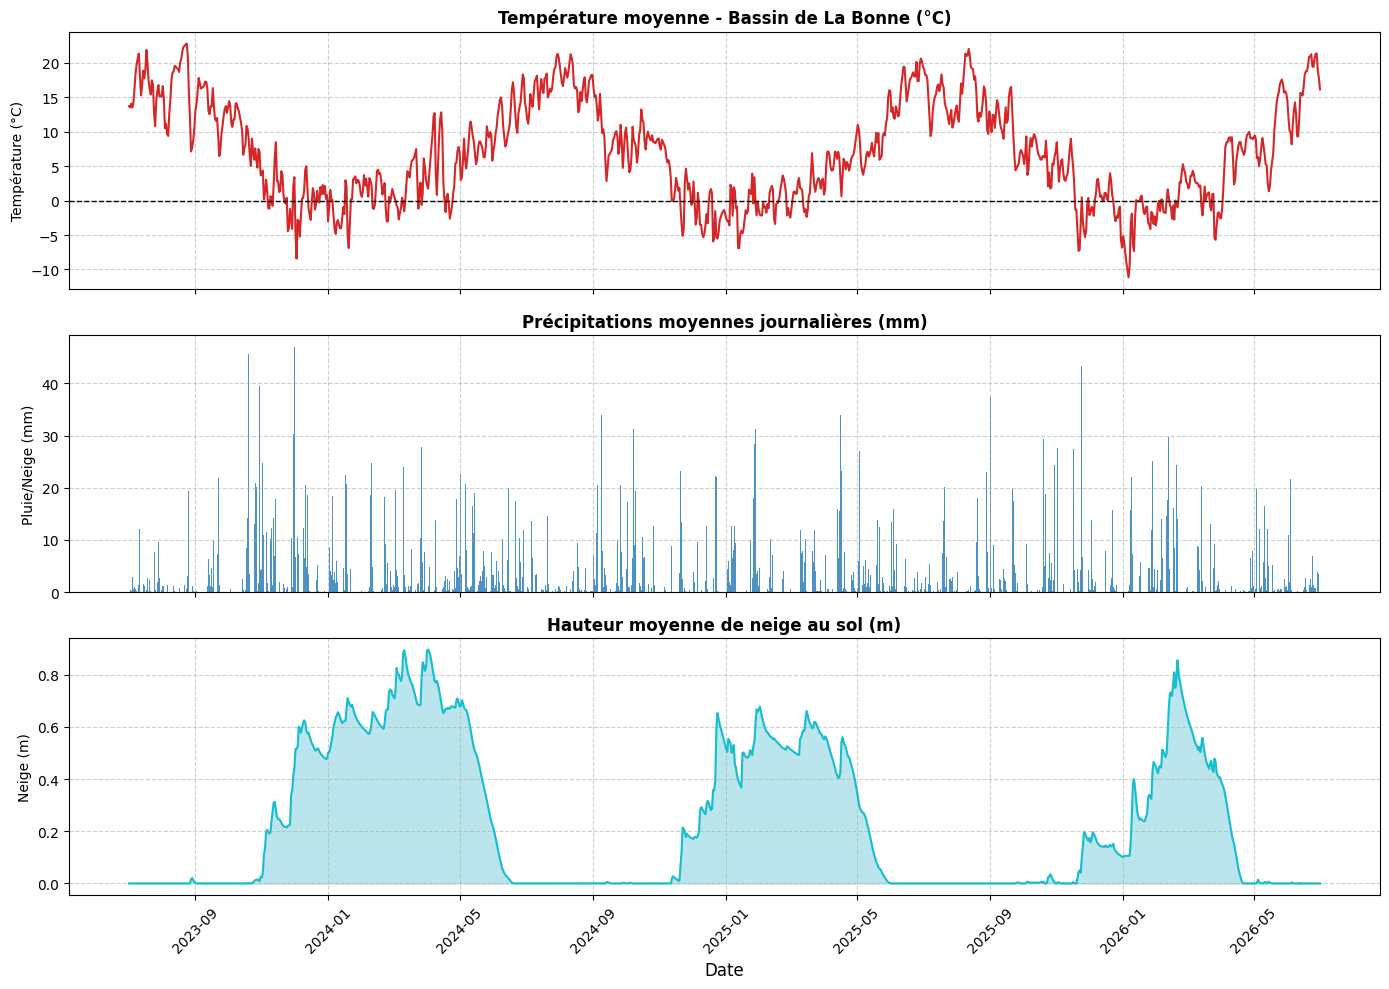

In [166]:
# Création d'une figure avec 3 sous-graphiques empilés
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# -------------------------------------------------------------------
# 1. Température (Courbe rouge)
# -------------------------------------------------------------------
ax1.plot(df_meteo_clean['date'], df_meteo_clean['temperature_bassin'], color='#d62728', linewidth=1.5)
ax1.set_title("Température moyenne - Bassin de La Bonne (°C)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Température (°C)")
ax1.grid(True, linestyle='--', alpha=0.6)
# Ajout d'une ligne horizontale à 0°C pour bien voir le point de gel/fonte
ax1.axhline(0, color='black', linewidth=1, linestyle='--')

# -------------------------------------------------------------------
# 2. Précipitations (Barres bleues)
# -------------------------------------------------------------------
ax2.bar(df_meteo_clean['date'], df_meteo_clean['precipitations_bassin'], color='#1f77b4', alpha=0.8)
ax2.set_title("Précipitations moyennes journalières (mm)", fontweight='bold', fontsize=12)
ax2.set_ylabel("Pluie/Neige (mm)")
ax2.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# 3. Neige au sol (Aire remplie cyan)
# -------------------------------------------------------------------
ax3.fill_between(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#9edae5', alpha=0.7)
ax3.plot(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#17becf', linewidth=1.5)
ax3.set_title("Hauteur moyenne de neige au sol (m)", fontweight='bold', fontsize=12)
ax3.set_ylabel("Neige (m)")
ax3.set_xlabel("Date", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Finitions
# -------------------------------------------------------------------
plt.xticks(rotation=45)
plt.tight_layout() # Évite que les labels ne se chevauchent
plt.show()

In [236]:
# ==========================================
# 1. FONCTIONS DE COLLECTE (Retournent des Pandas DataFrame pour la sécurité)
# ==========================================

def fetch_river_data(station_code, start_date, end_date):
    """Récupère le débit moyen journalier (QmnJ)"""
    url = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
    params = {
        "code_entite": station_code,
        "grandeur_hydro_elab": "QmnJ",
        "date_debut_obs_elab": pd.to_datetime(start_date).strftime('%Y-%m-%dT%H:%M:%SZ'),
        "date_fin_obs_elab": pd.to_datetime(end_date).strftime('%Y-%m-%dT%H:%M:%SZ'),
        "size": 20000,
        "sort": "asc"
    } 
    resp = requests.get(url, params=params)
    if resp.status_code in [200, 206]:
        data = resp.json().get('data', [])
        df = pd.DataFrame(data)[['date_obs_elab', 'resultat_obs_elab']]
        df = df.rename(columns={'date_obs_elab': 'date', 'resultat_obs_elab': 'debit_L_s'})
        df['date'] = pd.to_datetime(df['date'])
        return df
    else:
        raise Exception(f"Erreur Hub'Eau : {resp.status_code}")

def fetch_weather_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "daily": "rain_sum",
	    "hourly": ["temperature_2m", "snow_depth"],
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        # Extraction des données quotidiennes
        daily_rain_sum = data['daily']['rain_sum']
        daily_times = data['daily']['time']

        # Extraction et conversion des données horaires en quotidiennes
        hourly_snow_depth = pd.DataFrame(data['hourly'])
        hourly_snow_depth['time'] = pd.to_datetime(hourly_snow_depth['time'])
        daily_snow_depth = hourly_snow_depth.set_index('time')['snow_depth'].resample('D').mean().reset_index()
        hourly_temp = pd.DataFrame(data['hourly'])
        hourly_temp['time'] = pd.to_datetime(hourly_temp['time'])
        daily_temp = hourly_temp.set_index('time')['temperature_2m'].resample('D').mean().reset_index()

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'temperature_C': daily_temp['temperature_2m'],
            'precip_mm': daily_rain_sum,
            'snow_cm': daily_snow_depth['snow_depth']
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")


def fetch_temperature_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "daily": "temperature_2m_max",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        # Extraction des données quotidiennes
        daily_temp_max = data['daily']['temperature_2m_max']
        daily_times = data['daily']['time']

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'temperature_C': daily_temp_max,
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    

def fetch_rain_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "daily": "rain_sum",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        # Extraction des données quotidiennes

        daily_rain_sum = data['daily']['rain_sum']
        daily_times = data['daily']['time']

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'precip_mm': daily_rain_sum
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    
def fetch_snow_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "hourly": "snow_depth",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        daily_times = data['daily']['time']

        # Extraction et conversion des données horaires en quotidiennes
        hourly_snow_depth = pd.DataFrame(data['hourly'])
        hourly_snow_depth['time'] = pd.to_datetime(hourly_snow_depth['time'])
        daily_snow_depth = hourly_snow_depth.set_index('time')['snow_depth'].resample('D').mean().reset_index()

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'snow_cm': daily_snow_depth['snow_depth']
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")

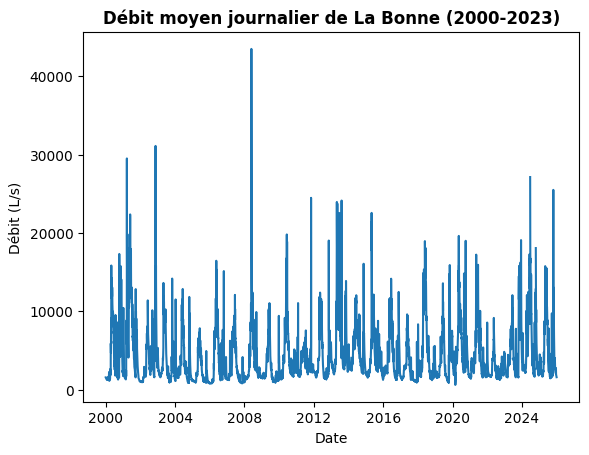

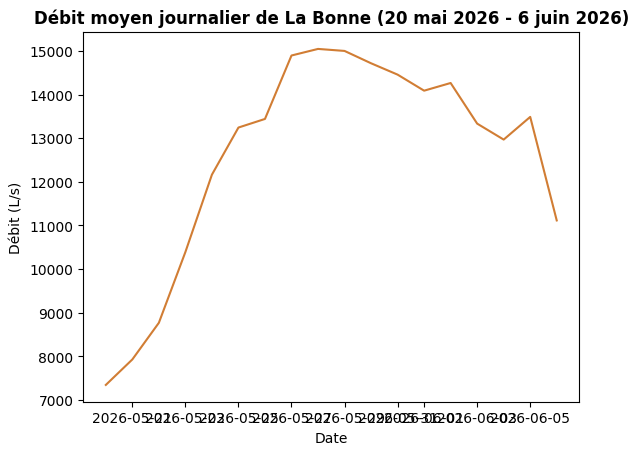

In [169]:
niveau_eau1 = fetch_river_data(station_code, datetime(2000, 1, 1), datetime(2025, 12, 31))
plt.plot(niveau_eau1['date'], niveau_eau1['debit_L_s'], color='#1f77b4')
plt.title("Débit moyen journalier de La Bonne (2000-2023)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Débit (L/s)")
plt.show()
niveau_eau2 = fetch_river_data(station_code, datetime(2026, 5, 20), datetime(2026, 6, 6))
plt.plot(niveau_eau2['date'], niveau_eau2['debit_L_s'], color="#D17D34")
plt.title("Débit moyen journalier de La Bonne (20 mai 2026 - 6 juin 2026)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Débit (L/s)")
plt.show()

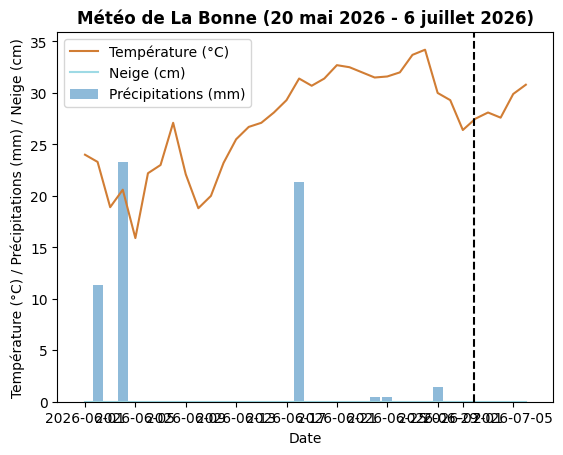

In [170]:
meteo_data = fetch_weather_data(44.9003, 5.9444, "2026-06-01", "2026-07-06")
plt.plot(meteo_data['date'], meteo_data['temperature_C'], color='#D17D34', label='Température (°C)')
plt.bar(meteo_data['date'], meteo_data['precip_mm'], color='#1f77b4', alpha=0.5, label='Précipitations (mm)')
plt.plot(meteo_data['date'], meteo_data['snow_cm'], color='#9edae5', label='Neige (cm)')
plt.title("Météo de La Bonne (20 mai 2026 - 6 juillet 2026)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Température (°C) / Précipitations (mm) / Neige (cm)")
plt.legend()
#bar verticale en poitiller aujourd'hui
plt.axvline(datetime.now(), color='black', linestyle='--', label="Aujourd'hui")
plt.show()

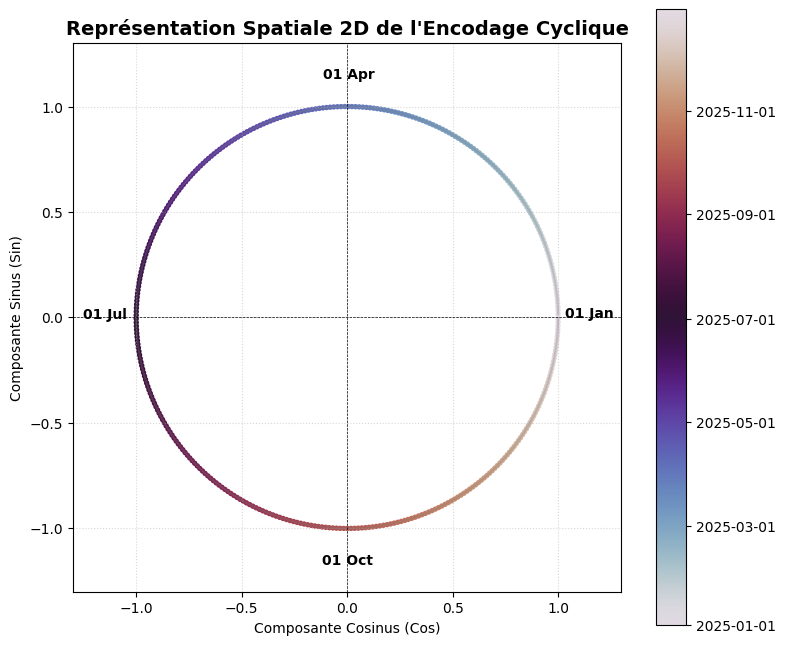

In [171]:
def encode_cyclical_date(date_obj):
    """Encode une date en deux composantes cycliques (sin, cos) pour éviter la cassure du Nouvel An."""
    day_of_year = date_obj.dayofyear
    days_in_year = 365.25 # Prise en compte des années bissextiles
    sin_date = np.sin(2 * np.pi * day_of_year / days_in_year)
    cos_date = np.cos(2 * np.pi * day_of_year / days_in_year)
    return [sin_date, cos_date]


import matplotlib.dates as mdates
# 1. Génération de la plage de dates
date_range = pd.date_range(start="2025-01-01", end="2025-12-31")

# En supposant que ton encodage génère un vecteur [sin, cos]
# (Adapté ici pour correspondre aux données attendues de ta fonction encode_cyclical_date)
cyclical_features = np.array([encode_cyclical_date(date) for date in date_range])

# Extraction des composantes Sinus (Y) et Cosinus (X)
# Note : Généralement cosinus est sur l'axe X et sinus sur l'axe Y pour tourner dans le sens trigo
x_cos = cyclical_features[:, 1]  # colonne pour cos
y_sin = cyclical_features[:, 0]  # colonne pour sin

# Convertir les dates en valeurs numériques pour que Matplotlib puisse créer l'échelle de couleur
colors = mdates.date2num(date_range)

# 2. Création du graphique
fig, ax = plt.subplots(figsize=(8, 8))  # Format carré (1:1) pour avoir un cercle parfait

scatter = ax.scatter(x_cos, y_sin, c=colors, cmap='twilight', s=15, edgecolors='none')

# Relier les points par une fine ligne grise pour bien marquer la continuité du cercle
ax.plot(x_cos, y_sin, color='gray', alpha=0.3, linestyle='-')

# Ajouter des repères textuels sur le cercle pour les moments clés (Changement de saison / Trimestre)
# On prend quelques indices répartis dans l'année (ex: 1er Janvier, 1er Avril, 1er Juillet, 1er Octobre)
indices_labels = [0, 90, 181, 273] 
for idx in indices_labels:
    date_label = date_range[idx].strftime('%d %b')
    # Petit décalage (1.15) pour écrire le texte légèrement à l'extérieur du cercle unité
    ax.text(x_cos[idx] * 1.15, y_sin[idx] * 1.15, date_label, 
            fontsize=10, fontweight='bold', ha='center', va='center')

# 3. Esthétique et mise en forme autour de l'origine
ax.axhline(0, color='black', linewidth=0.5, linestyle='--') # Axe X
ax.axvline(0, color='black', linewidth=0.5, linestyle='--') # Axe Y

ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.set_aspect('equal') # Force le ratio 1:1 pour éviter que le cercle ressemble à une ellipse

ax.set_title("Représentation Spatiale 2D de l'Encodage Cyclique", fontweight='bold', fontsize=14)
ax.set_xlabel("Composante Cosinus (Cos)")
ax.set_ylabel("Composante Sinus (Sin)")
ax.grid(True, linestyle=':', alpha=0.5)

# 4. Configuration de la barre de couleur (Échelle des dates)
cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', shrink=0.8)

# Formater les graduations de la colorbar pour afficher de vraies dates au lieu de nombres
# On affiche un marqueur tous les 2 mois pour ne pas surcharger
cbar.ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()
plt.show()


## Régression linéaire
entré : météo de 5 jours avant à 15 jours après; débit 5 jours avant, date (sin/cos), date cyclique

sortie : débit des 15 prochain jours

In [446]:
# ==========================================
# 1. PARAMÈTRES ET TÉLÉCHARGEMENT GLOBAL
# ==========================================
STATION = "W231401001"
LAT, LON = 44.913963, 6.128593

# On prend des marges aux extrémités pour pouvoir faire nos décalages (shift) 
# sans perdre le 1er janvier 2000 ou le 31 décembre 2025.
START_FETCH = "2000-01-01"
END_FETCH = "2026-06-15"

df_eau = fetch_river_data(STATION, START_FETCH, END_FETCH)
df_meteo = fetch_weather_data(LAT, LON, START_FETCH, END_FETCH)

df = pd.merge(df_eau, df_meteo, on='date', how='inner')


In [447]:
past_day = 20
predict_day = 15

# ==========================================
# 2. CONSTRUCTION DES ENTRÉES (X) ET SORTIES (Y)
# ==========================================
features_X = []
targets_Y = []

# --- A. L'historique de la rivière (J-5 à J-1) ---
for i in range(1, past_day + 1):
    nom_col = f"debit_J-{i}"
    df[nom_col] = df['debit_L_s'].shift(i)
    features_X.append(nom_col)

# --- B. La Météo passée (J-5 à J-1) ---
for i in range(1, past_day + 1):
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        nom_col = f"{var}_J-{i}"
        df[nom_col] = df[var].shift(i)
        features_X.append(nom_col)

# --- C. La Météo future et actuelle (J0 à J+14) ---
# shift(-i) remonte les données futures sur la ligne actuelle
for i in range(0, max(15, predict_day + 1)):
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        nom_col = f"{var}_J+{i}"
        df[nom_col] = df[var].shift(-i)
        features_X.append(nom_col)

# --- D. La Date cyclique ---
df['sin_date'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['cos_date'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)
features_X.extend(['sin_date', 'cos_date'])

# --- E. La Sortie Y : Débit de la rivière de J0 à J+14 ---
for i in range(0, predict_day + 1):
    nom_col = f"cible_debit_J+{i}"
    df[nom_col] = df['debit_L_s'].shift(-i)
    targets_Y.append(nom_col)

# On supprime toutes les lignes incomplètes créées par les décalages (shift)
df = df.dropna()

# ==========================================
# 3. SÉPARATION TRAIN / TEST
# ==========================================
print("3. Séparation Entraînement / Test...")
# Entraînement strict de 2000 à fin 2020
train = df[(df['date'] >= "2000-01-01") & (df['date'] <= "2020-12-31")]
# Test sur 2021 à 2025
test = df[(df['date'] >= "2021-01-01") & (df['date'] <= "2025-12-31")]

X_train, Y_train = train[features_X], train[targets_Y]
X_test, Y_test = test[features_X], test[targets_Y]

3. Séparation Entraînement / Test...


/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/4209199064.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[nom_col] = df[var].shift(-i)
/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/4209199064.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[nom_col] = df[var].shift(-i)
/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/4209199064.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

In [448]:
model_lin = LinearRegression()
model_lin.fit(X_train, Y_train)

# Prédiction sur l'année 2025
predictions = model_lin.predict(X_test)

# multioutput='raw_values' permet d'avoir le score séparé pour chaque jour du futur
scores_r2_lin = r2_score(Y_test, predictions, multioutput='raw_values')

print("\n--- RÉSULTATS DE PRÉVISION SUR 2025 ---")
for i, score in enumerate(scores_r2_lin):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS DE PRÉVISION SUR 2025 ---
Prévision J0 (Aujourd'hui) : R² =  92.0 %
Prévision J+1             : R² =  86.3 %
Prévision J+2             : R² =  82.6 %
Prévision J+3             : R² =  79.3 %
Prévision J+4             : R² =  76.6 %
Prévision J+5             : R² =  74.0 %
Prévision J+6             : R² =  72.1 %
Prévision J+7             : R² =  69.7 %
Prévision J+8             : R² =  67.2 %
Prévision J+9             : R² =  65.1 %
Prévision J+10            : R² =  63.0 %
Prévision J+11            : R² =  61.1 %
Prévision J+12            : R² =  59.3 %
Prévision J+13            : R² =  57.8 %
Prévision J+14            : R² =  56.2 %
Prévision J+15            : R² =  54.8 %


In [463]:
def tracer_prediction(df_global, data_split, model, features_X, date_cible_str, titre="Graphique"):
    """
    Trace le débit avec continuité parfaite, axe X forcé pour inclure le passé,
    et axe Y plafonné intelligemment.
    """
    date_cible = pd.to_datetime(date_cible_str)
    
    # 1. Vérification de la présence de la date
    ligne_J0 = data_split[data_split['date'] == date_cible]
    if ligne_J0.empty:
        print(f"❌ La date '{date_cible_str}' n'est pas disponible dans ce bloc ({titre}).")
        return
        
    # Re-génération locale des noms de colonnes cibles (Y)
    targets_Y = [f"cible_debit_J+{i}" for i in range(predict_day + 1)]
        
    # 2. Récupération du passé (15 jours avant J0, inclus)
    contexte = df_global[(df_global['date'] >= date_cible - pd.Timedelta(days=15)) & 
                         (df_global['date'] <= date_cible)]
    
    # 3. Prédictions
    X_input = ligne_J0[features_X]
    Y_vrai_futur = ligne_J0[targets_Y].values[0]
    Y_pred_futur = model.predict(X_input)[0]
    
    # 4. Raccordement au point J0 pour continuité visuelle
    debit_actuel = ligne_J0['debit_L_s'].values[0]
    dates_futures = [date_cible] + list(pd.date_range(start=date_cible + pd.Timedelta(days=1), periods=predict_day+1))
    Y_vrai_continu = [debit_actuel] + list(Y_vrai_futur)
    Y_pred_continu = [debit_actuel] + list(Y_pred_futur)
    
    # --- NOUVEAU : Calcul de la limite de l'axe Y ---
    # On prend le max absolu de tout ce qu'on affiche
    max_affiche = max(
        contexte['debit_L_s'].max() if not contexte.empty else 0,
        max(Y_vrai_continu),
        max(Y_pred_continu)
    )
    # On ajoute +10% de marge en haut pour aérer, sans jamais dépasser 12000
    limite_y = max(12000, max_affiche * 1.1)

    # ==========================================
    # 5. VISUALISATION ÉPURÉE
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Tracés
    plt.plot(contexte['date'], contexte['debit_L_s'], color='black', linewidth=2.5, label="Passé (Hub'Eau)")
    plt.plot(dates_futures, Y_vrai_continu, color='blue', marker='o', linestyle=':', linewidth=2, label="Vrai Futur (Réalité)")
    plt.plot(dates_futures, Y_pred_continu, color='red', marker='X', linestyle='-', linewidth=2, label="Prédiction")
    
    # Formatage strict
    plt.axvline(date_cible, color='grey', linestyle='--', alpha=0.7)
    
    # --- NOUVEAU : Forcer explicitement le cadre ---
    plt.xlim(left=date_cible - pd.Timedelta(days=15), right=dates_futures[-1])
    plt.ylim(bottom=0, top=limite_y)
    
    # Inclinaison des dates pour éviter qu'elles ne se superposent
    plt.xticks(rotation=45, ha='right')
    
    plt.title(f"{titre} (Départ : {date_cible.strftime('%Y-%m-%d')})", fontweight='bold', fontsize=14)
    plt.ylabel("Débit (L/s)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


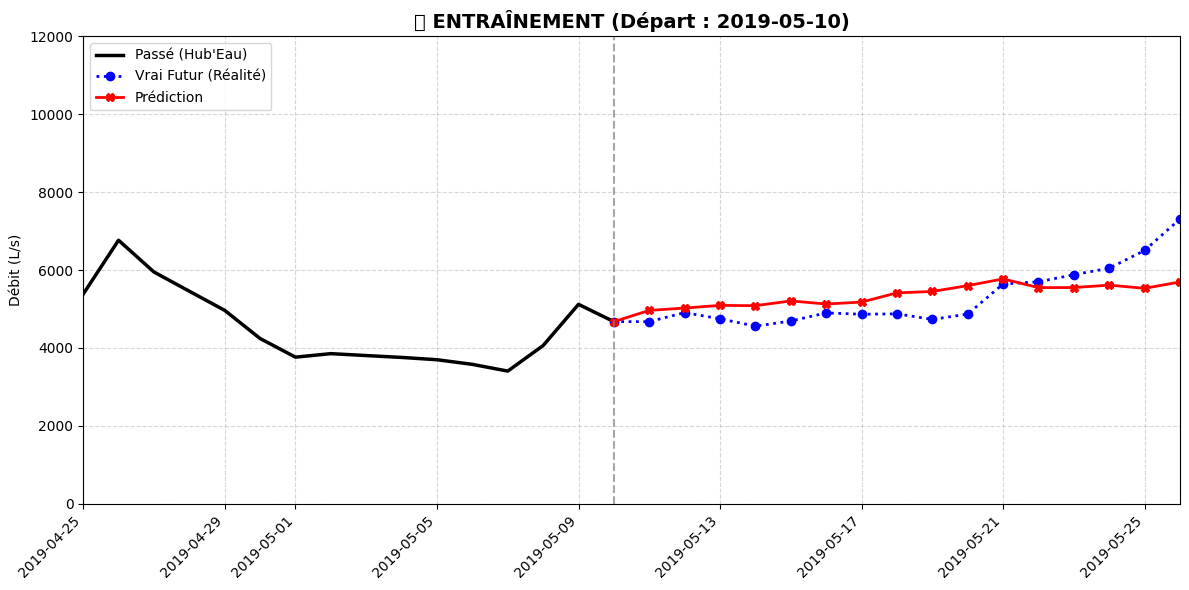

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


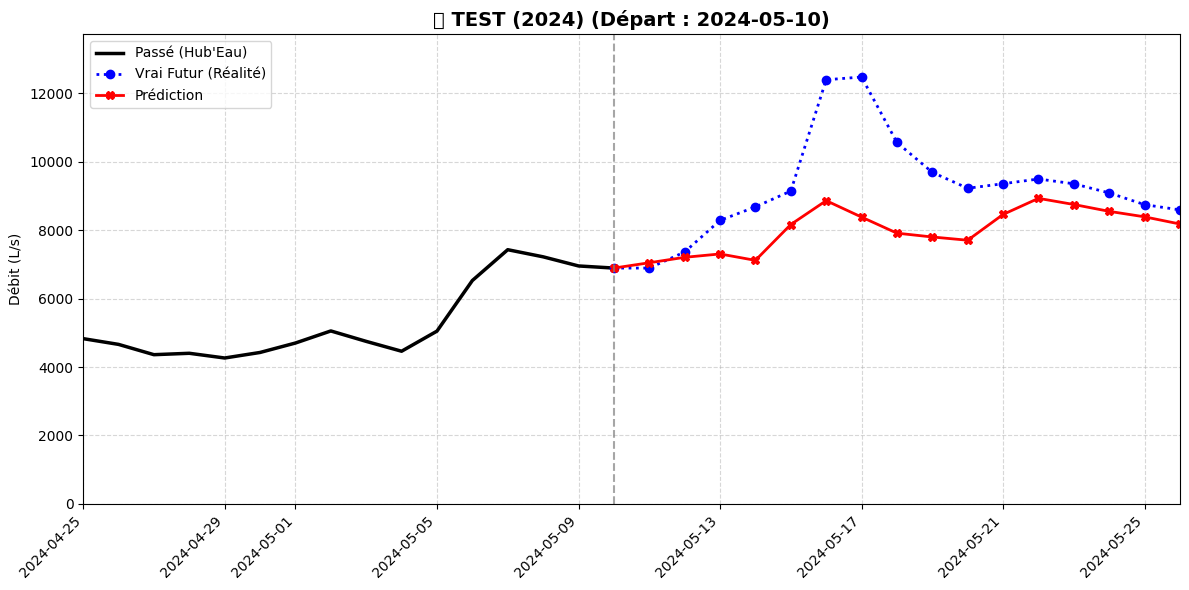

In [459]:
# ==========================================
# APPELS DES TRACÉS
# ==========================================
tracer_prediction(df, train, model_lin, features_X, "2019-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_lin, features_X, "2024-05-10", "🔴 TEST (2024)")

In [331]:
# 1. Dates dynamiques
aujourdhui = pd.Timestamp.now().normalize()
start_live = (aujourdhui - timedelta(days=25)).strftime('%Y-%m-%d')
end_live = (aujourdhui + timedelta(days=15)).strftime('%Y-%m-%d')

# 2. Téléchargement et Fusion
df_eau_live = fetch_river_data(STATION, start_live, aujourdhui.strftime('%Y-%m-%d'))
df_meteo_live = fetch_weather_data(LAT, LON, start_live, end_live)
df = pd.merge(df_meteo_live, df_eau_live, on='date', how='left')

# 3. Construction brute des variables (l'ordre n'a plus d'importance ici)
for i in range(1, 6):
    df[f"debit_J-{i}"] = df['debit_L_s'].shift(i)
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        df[f"{var}_J-{i}"] = df[var].shift(i)

for i in range(15):
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        df[f"{var}_J+{i}"] = df[var].shift(-i)

df['sin_date'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['cos_date'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)

# 4. Extraction de J0 avec l'ordre strict imposé par le modèle
# model.feature_names_in_ contient l'ordre parfait de l'entraînement
features_ordonnees = model_lin.feature_names_in_



ligne_J0 = df.iloc[-1:]
date_J0 = ligne_J0['date'].iloc[0]

# Inférence : Le modèle est content, l'ordre est parfait
X_live = ligne_J0[features_ordonnees]
Y_pred_live = model_lin.predict(X_live)[0]

# 5. Visualisation avec Raccordement Parfait
date_J_moins_1 = date_J0 - pd.Timedelta(days=1)

# Contexte (Noir) jusqu'à J-1 inclus
contexte = df[(df['date'] >= date_J0 - pd.Timedelta(days=15)) & (df['date'] <= date_J_moins_1)]

# Préparation de la courbe rouge pour la continuité
vrai_debit_J_moins_1 = ligne_J0['debit_J-1'].iloc[0]

# On ajoute la date et la valeur de J-1 au tout début des prédictions (J0 à J+14)
dates_rouges = [date_J_moins_1] + list(pd.date_range(start=date_J0, periods=15))
valeurs_rouges = [vrai_debit_J_moins_1] + list(Y_pred_live)

# Tracés
plt.figure(figsize=(12, 6))
plt.plot(contexte['date'], contexte['debit_L_s'], color='black', linewidth=2.5, label="Passé (Hub'Eau)")
plt.plot(dates_rouges, valeurs_rouges, color='red', marker='X', linestyle='-', linewidth=2, label="Prédiction")

# Formatage strict
plt.axvline(date_J0, color='grey', linestyle='--')
plt.ylim(bottom=0)
plt.title(f"Prévision en direct (Départ : {date_J0.strftime('%Y-%m-%d')})", fontweight='bold')
plt.ylabel("Débit (L/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: "['debit_J-6', 'debit_J-7', 'debit_J-8', 'debit_J-9', 'debit_J-10', 'debit_J-11', 'debit_J-12', 'debit_J-13', 'debit_J-14', 'debit_J-15', 'debit_J-16', 'debit_J-17', 'debit_J-18', 'debit_J-19', 'debit_J-20', 'temperature_C_J-6', 'precip_mm_J-6', 'snow_cm_J-6', 'temperature_C_J-7', 'precip_mm_J-7', 'snow_cm_J-7', 'temperature_C_J-8', 'precip_mm_J-8', 'snow_cm_J-8', 'temperature_C_J-9', 'precip_mm_J-9', 'snow_cm_J-9', 'temperature_C_J-10', 'precip_mm_J-10', 'snow_cm_J-10', 'temperature_C_J-11', 'precip_mm_J-11', 'snow_cm_J-11', 'temperature_C_J-12', 'precip_mm_J-12', 'snow_cm_J-12', 'temperature_C_J-13', 'precip_mm_J-13', 'snow_cm_J-13', 'temperature_C_J-14', 'precip_mm_J-14', 'snow_cm_J-14', 'temperature_C_J-15', 'precip_mm_J-15', 'snow_cm_J-15', 'temperature_C_J-16', 'precip_mm_J-16', 'snow_cm_J-16', 'temperature_C_J-17', 'precip_mm_J-17', 'snow_cm_J-17', 'temperature_C_J-18', 'precip_mm_J-18', 'snow_cm_J-18', 'temperature_C_J-19', 'precip_mm_J-19', 'snow_cm_J-19', 'temperatu


--- DÉBIT DE BASE ESTIMÉ (Biais B par jour) ---
Biais pour J+0 : -6.64 L/s
Biais pour J+1 : -20.18 L/s
Biais pour J+2 : -32.37 L/s
Biais pour J+3 : -38.01 L/s
Biais pour J+4 : -34.53 L/s
Biais pour J+5 : -34.07 L/s
Biais pour J+6 : -27.38 L/s
Biais pour J+7 : -21.03 L/s
Biais pour J+8 : -23.70 L/s
Biais pour J+9 : -33.31 L/s
Biais pour J+10 : -45.76 L/s
Biais pour J+11 : -56.64 L/s
Biais pour J+12 : -74.30 L/s
Biais pour J+13 : -77.82 L/s
Biais pour J+14 : -81.07 L/s
Biais pour J+15 : -104.26 L/s


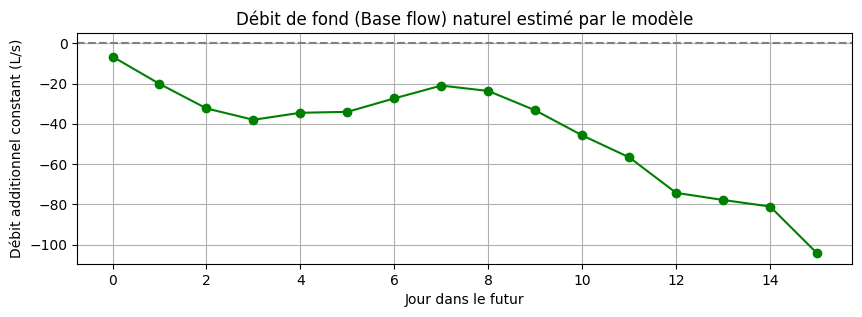

In [332]:
# --- Extraction du vecteur de constante B ---
# model.intercept_ contient le vecteur de biais pour tes 15 jours de sortie
biais_vecteur = model_lin.intercept_

# Affichage pour les 15 jours
print("\n--- DÉBIT DE BASE ESTIMÉ (Biais B par jour) ---")
for i, b in enumerate(biais_vecteur):
    print(f"Biais pour J+{i} : {b:.2f} L/s")

# --- Visualisation rapide du vecteur ---
plt.figure(figsize=(10, 3))
plt.plot(range(predict_day + 1), biais_vecteur, marker='o', color='green', label="Apport souterrain estimé")
plt.axhline(0, color='grey', linestyle='--')
plt.title("Débit de fond (Base flow) naturel estimé par le modèle")
plt.xlabel("Jour dans le futur")
plt.ylabel("Débit additionnel constant (L/s)")
plt.grid(True)
plt.show()

## Polynomiale

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

In [464]:
model_pl = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=100))
model_pl.fit(X_train, Y_train)

# Prédiction sur l'année 2025
predictions = model_pl.predict(X_test)

# multioutput='raw_values' permet d'avoir le score séparé pour chaque jour du futur
scores_r2_pl = r2_score(Y_test, predictions, multioutput='raw_values')

print("\n--- RÉSULTATS DE PRÉVISION SUR 2025 ---")
for i, score in enumerate(scores_r2_pl):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<predict_day} : R² = {score * 100:>5.1f} %")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(



--- RÉSULTATS DE PRÉVISION SUR 2025 ---


ValueError: Invalid format specifier '<predict_day' for object of type 'str'

In [461]:
tracer_prediction(df, train, model_pl, features_X, "2019-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_pl, features_X, "2024-05-10", "🔴 TEST (2024)")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- precip_mm_J+16
- precip_mm_J+17
- precip_mm_J+18
- precip_mm_J+19
- precip_mm_J+20
- ...


## Chercher le bassin versan

In [ ]:
import optuna
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import itertools
import time

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Random Forest

In [441]:
# Instanciation et entraînement
model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_rf = model_rf.predict(X_test)

# Évaluation jour par jour
scores_r2_rf = r2_score(Y_test, predictions_rf, multioutput='raw_values')

print("\n--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---")
for i, score in enumerate(scores_r2_rf):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---
Prévision J0 (Aujourd'hui) : R² =  90.6 %
Prévision J+1             : R² =  85.2 %
Prévision J+2             : R² =  81.8 %
Prévision J+3             : R² =  78.4 %
Prévision J+4             : R² =  75.7 %
Prévision J+5             : R² =  74.6 %
Prévision J+6             : R² =  74.0 %
Prévision J+7             : R² =  73.0 %
Prévision J+8             : R² =  72.1 %
Prévision J+9             : R² =  71.0 %
Prévision J+10            : R² =  69.6 %
Prévision J+11            : R² =  68.1 %
Prévision J+12            : R² =  67.2 %
Prévision J+13            : R² =  66.1 %
Prévision J+14            : R² =  65.5 %
Prévision J+15            : R² =  64.0 %


/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


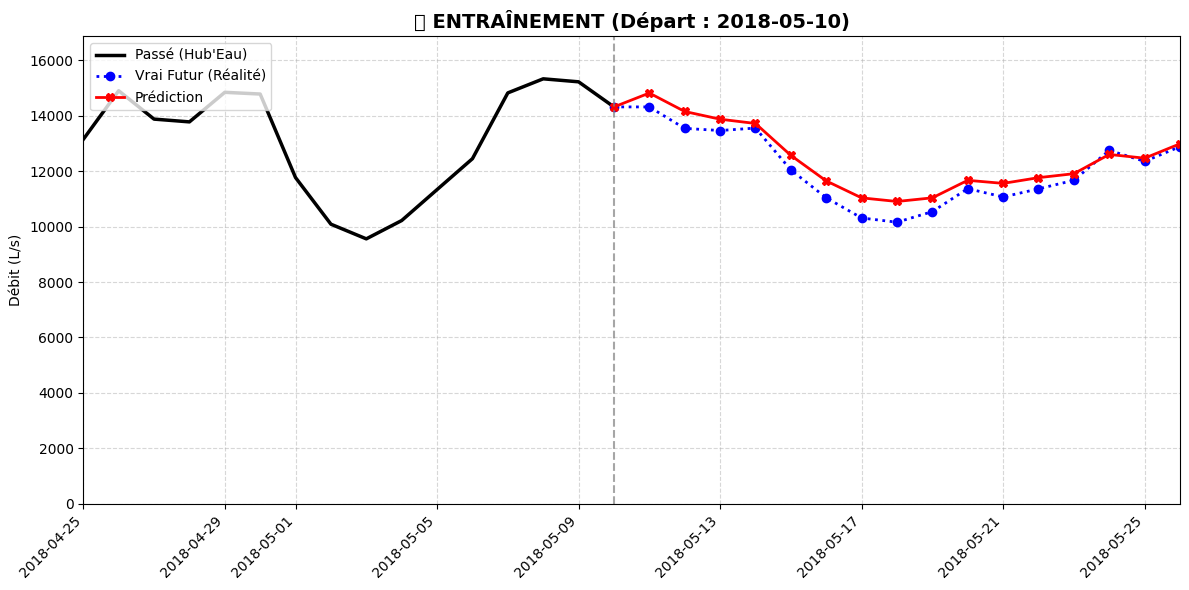

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


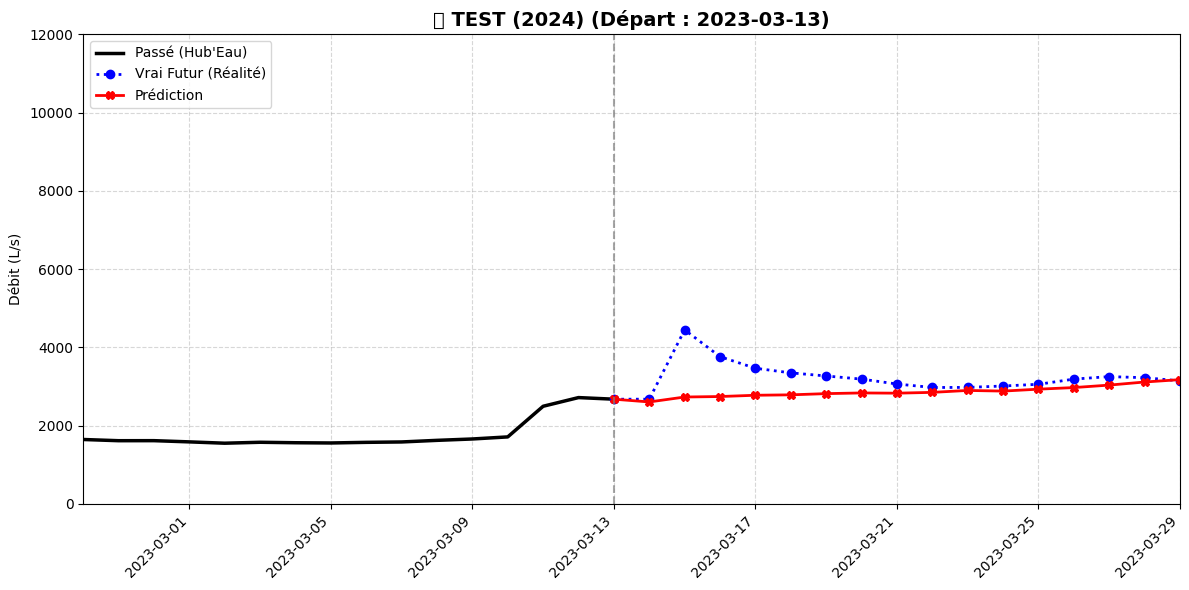

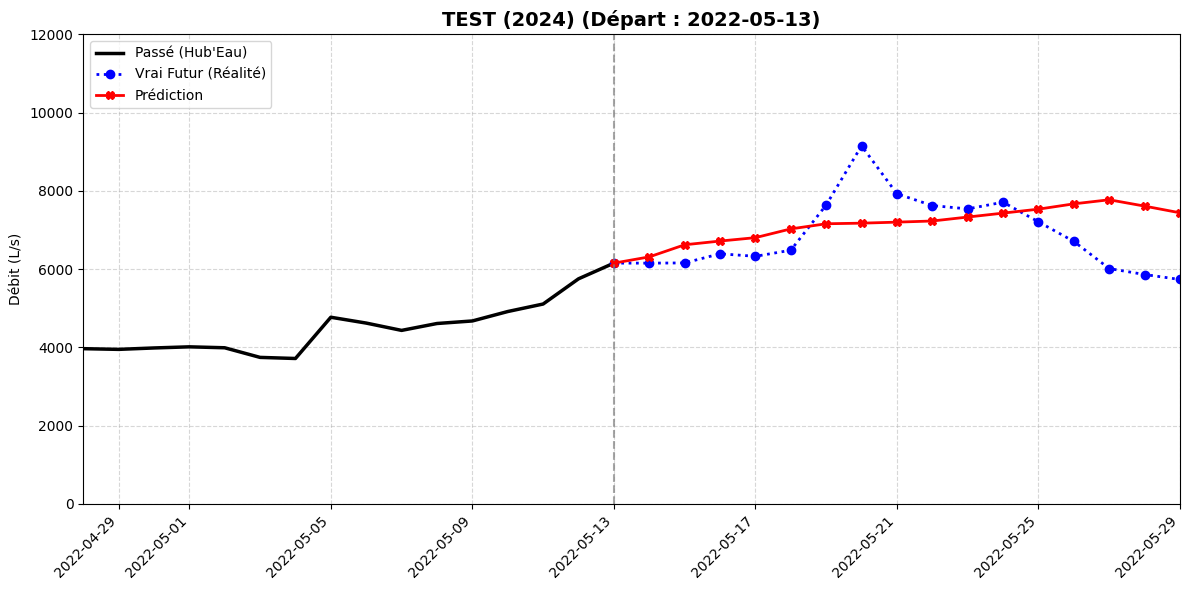

In [466]:
tracer_prediction(df, train, model_rf, features_X, "2018-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_rf, features_X, "2023-03-13", "🔴 TEST (2024)")
tracer_prediction(df, test, model_rf, features_X, "2022-05-13", "TEST (2024)")

## BOOSTING

In [437]:
# Instanciation du modèle de base, enveloppé pour supporter les 15 dimensions de Y
modele_de_base_gb = HistGradientBoostingRegressor(random_state=42, l2_regularization=0.1)
model_gb = MultiOutputRegressor(modele_de_base_gb)

# Entraînement
model_gb.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_gb = model_gb.predict(X_test)

# Évaluation jour par jour
scores_r2_gb = r2_score(Y_test, predictions_gb, multioutput='raw_values')

print("\n--- RÉSULTATS GRADIENT BOOSTING ---")
for i, score in enumerate(scores_r2_gb):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS GRADIENT BOOSTING ---
Prévision J0 (Aujourd'hui) : R² =  92.9 %
Prévision J+1             : R² =  88.2 %
Prévision J+2             : R² =  85.0 %
Prévision J+3             : R² =  82.0 %
Prévision J+4             : R² =  79.7 %
Prévision J+5             : R² =  77.2 %
Prévision J+6             : R² =  76.0 %
Prévision J+7             : R² =  74.8 %
Prévision J+8             : R² =  72.9 %
Prévision J+9             : R² =  72.4 %
Prévision J+10            : R² =  71.6 %
Prévision J+11            : R² =  70.9 %
Prévision J+12            : R² =  69.9 %
Prévision J+13            : R² =  69.4 %
Prévision J+14            : R² =  69.3 %
Prévision J+15            : R² =  68.2 %


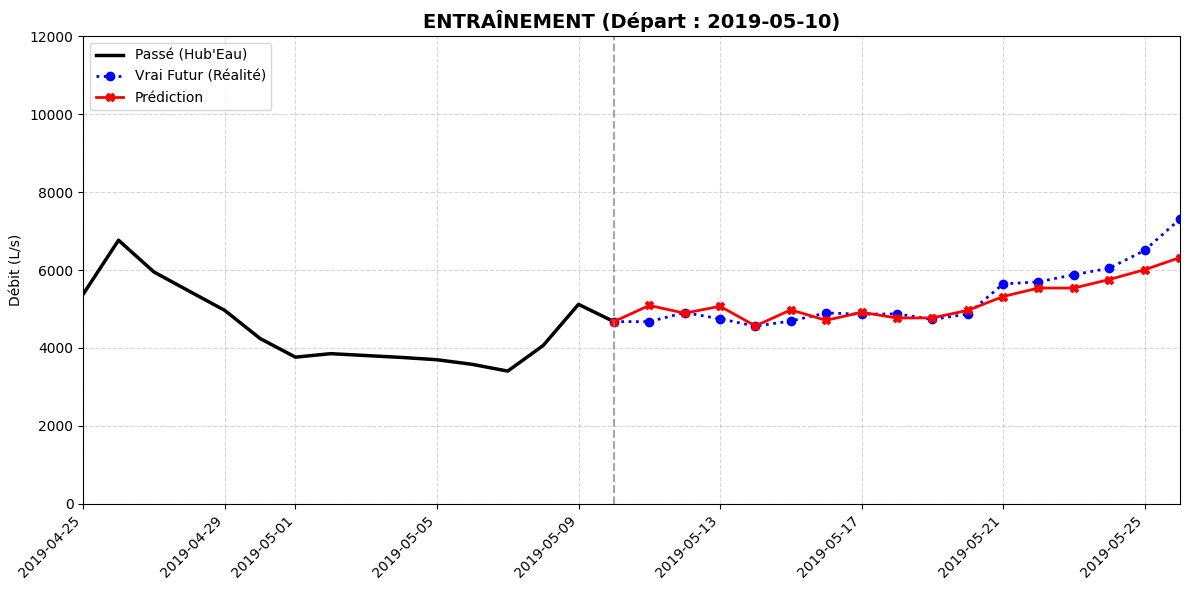

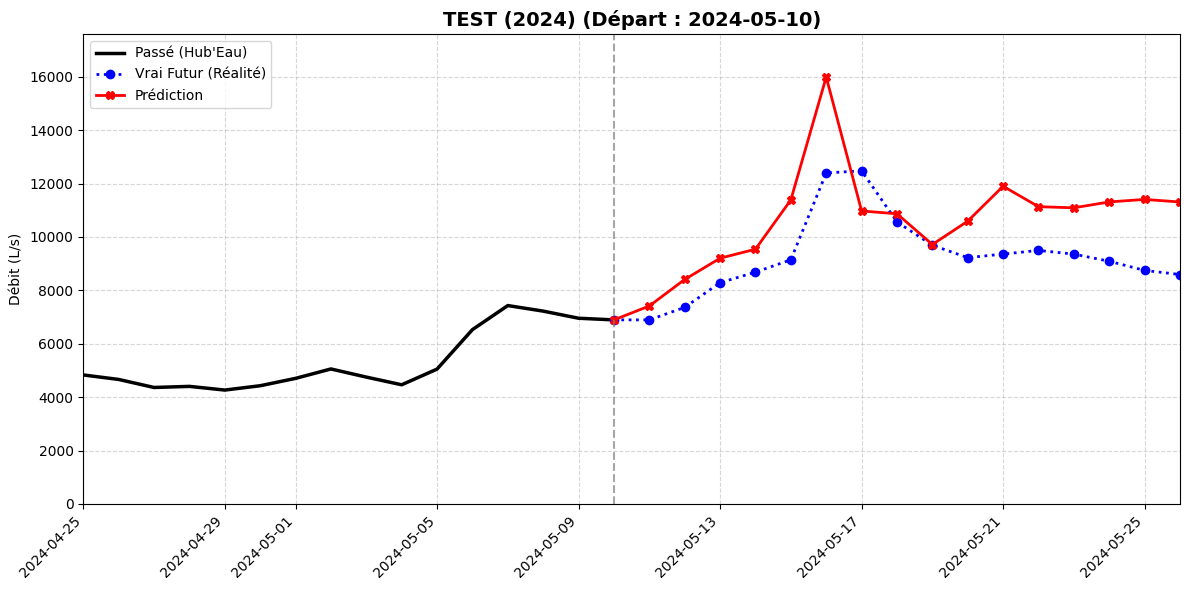

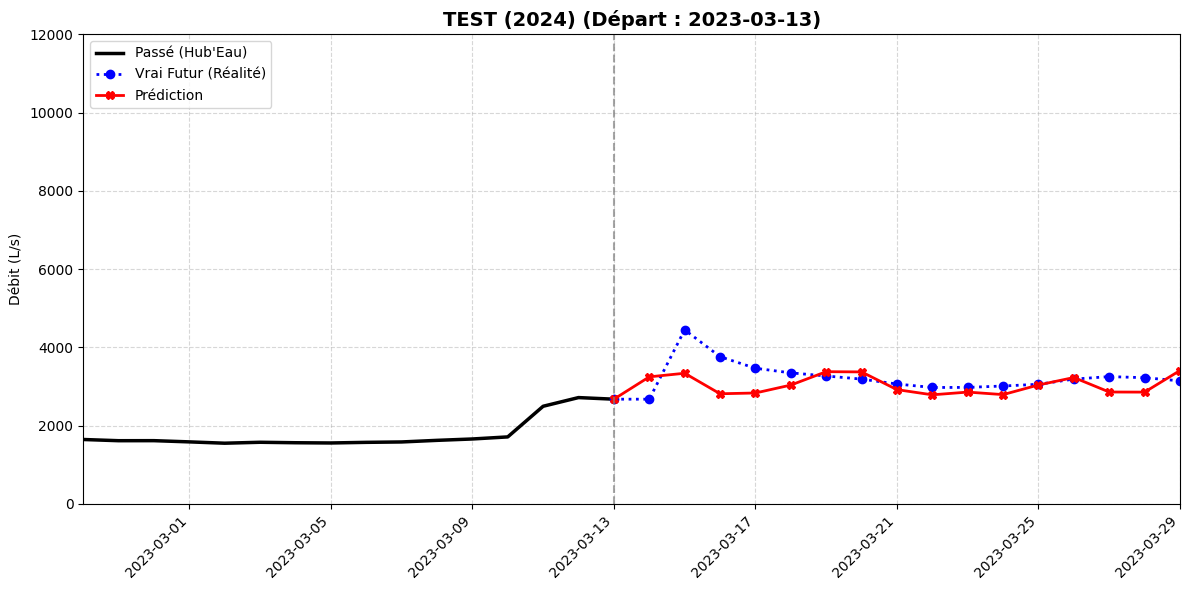

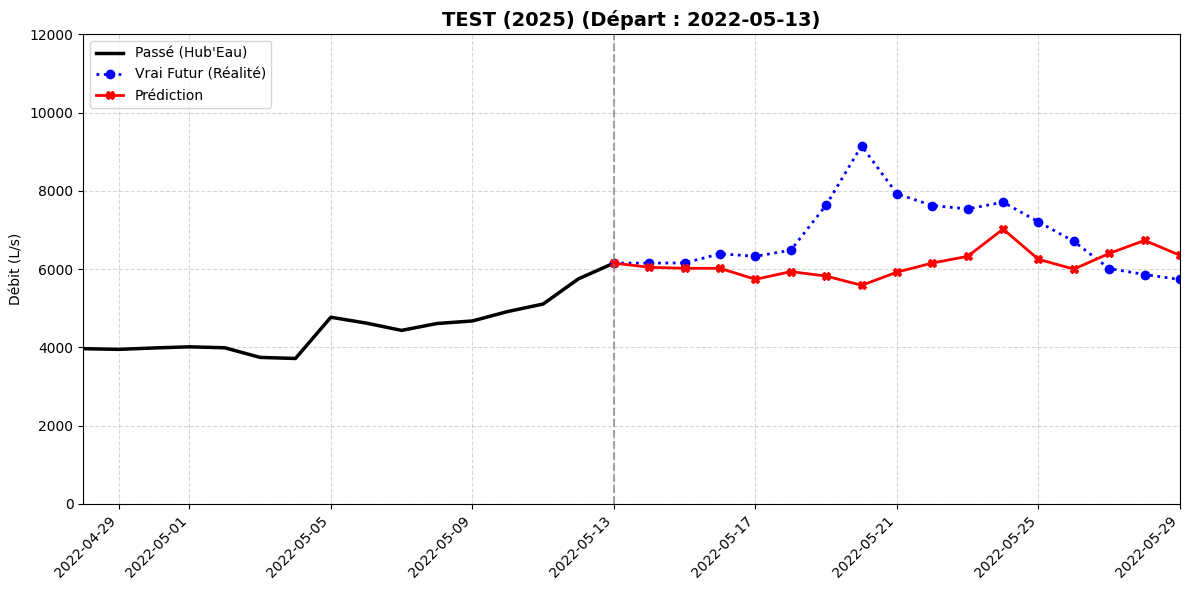

In [468]:
tracer_prediction(df, train, model_gb, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_gb, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_gb, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_gb, features_X, "2022-05-13", "TEST (2025)")

In [417]:
# Un réseau avec 2 couches cachées de 100 et 50 neurones

model_nn = MLPRegressor(
    # 1. L'ARCHITECTURE : (128, 64) signifie une 1ère couche de 128 neurones, puis 64. 
    # Tu peux tester plus profond : (128, 64, 32) ou plus large : (200, 100)
    hidden_layer_sizes=(64, 32), 
    

    
    # 3. LA TAILLE DU LOT (Batch Size) : Le nombre de lignes lues avant de mettre à jour le modèle.
    # Scikit-Learn met 200 par défaut. Essaie 32 ou 64 pour aider le modèle à généraliser.
    batch_size=64,
    
    # 4. LA RÉGULARISATION (Alpha) : C'est l'équivalent du "Dropout". 
    # Ça pénalise les poids trop gros pour empêcher le modèle d'apprendre par cœur (overfitting).
    alpha=100,
    
    activation='relu',
    solver='adam',
    random_state=42
)
# Entraînement
model_nn.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_nn = model_nn.predict(X_test)

# Évaluation jour par jour
scores_r2_nn = r2_score(Y_test, predictions_nn, multioutput='raw_values')

print("\n--- RÉSULTATS RESEAUX DE NEURONES ---")
for i, score in enumerate(scores_r2_nn):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")




--- RÉSULTATS RESEAUX DE NEURONES ---
Prévision J0 (Aujourd'hui) : R² =  91.1 %
Prévision J+1             : R² =  85.6 %
Prévision J+2             : R² =  82.0 %
Prévision J+3             : R² =  78.1 %
Prévision J+4             : R² =  74.6 %
Prévision J+5             : R² =  72.2 %
Prévision J+6             : R² =  70.9 %
Prévision J+7             : R² =  69.8 %
Prévision J+8             : R² =  68.5 %
Prévision J+9             : R² =  66.4 %
Prévision J+10            : R² =  64.7 %
Prévision J+11            : R² =  64.3 %
Prévision J+12            : R² =  64.2 %
Prévision J+13            : R² =  63.7 %
Prévision J+14            : R² =  62.9 %
Prévision J+15            : R² =  60.6 %


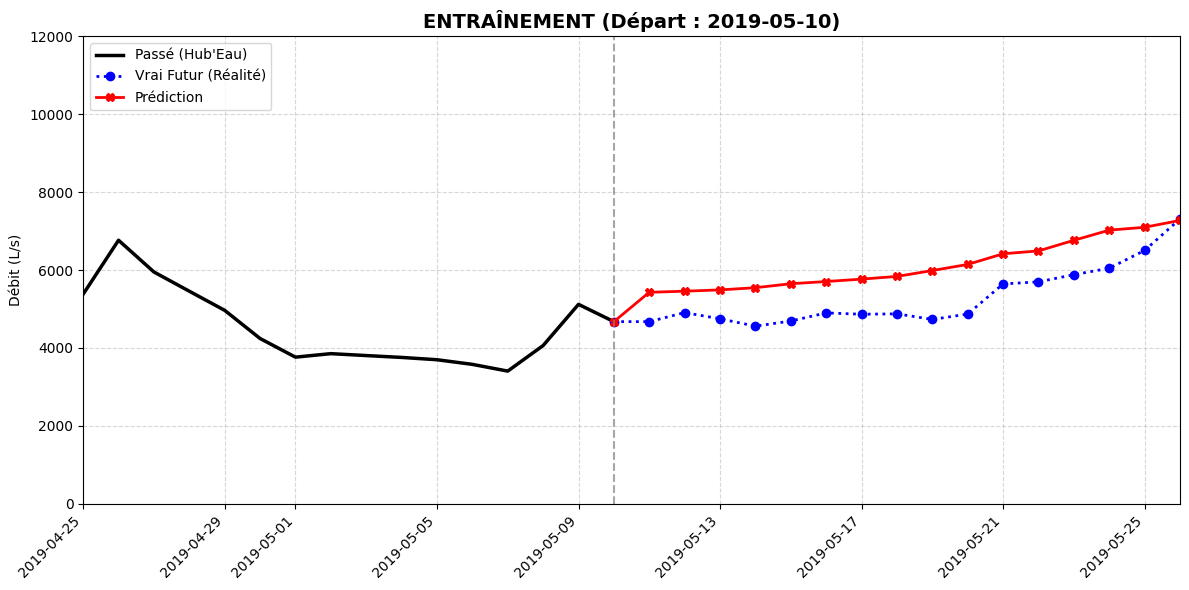

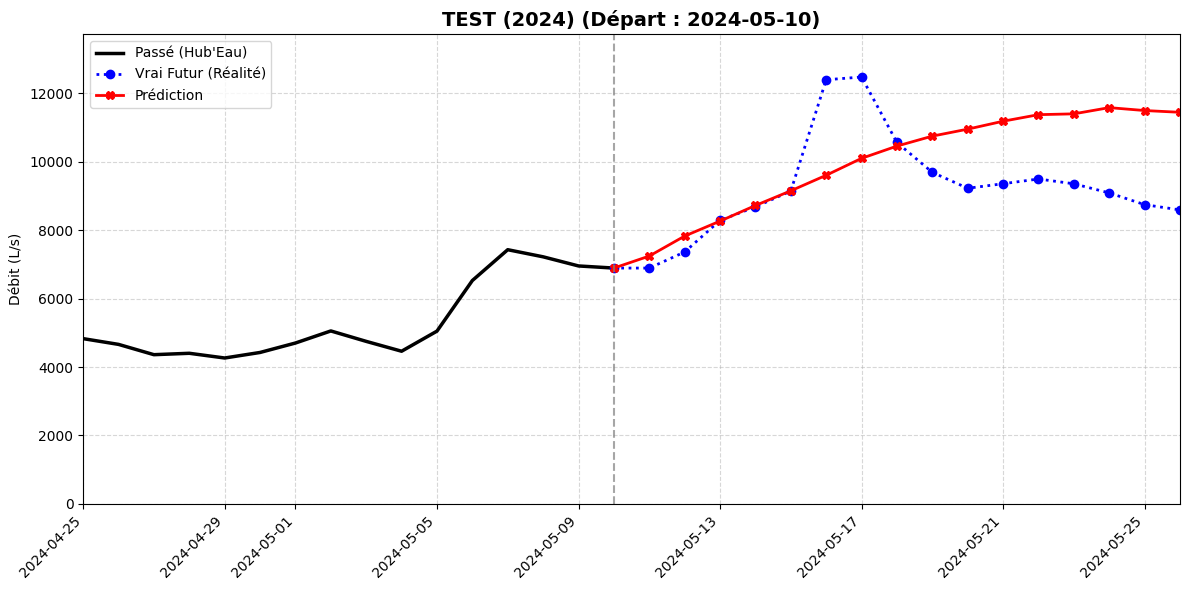

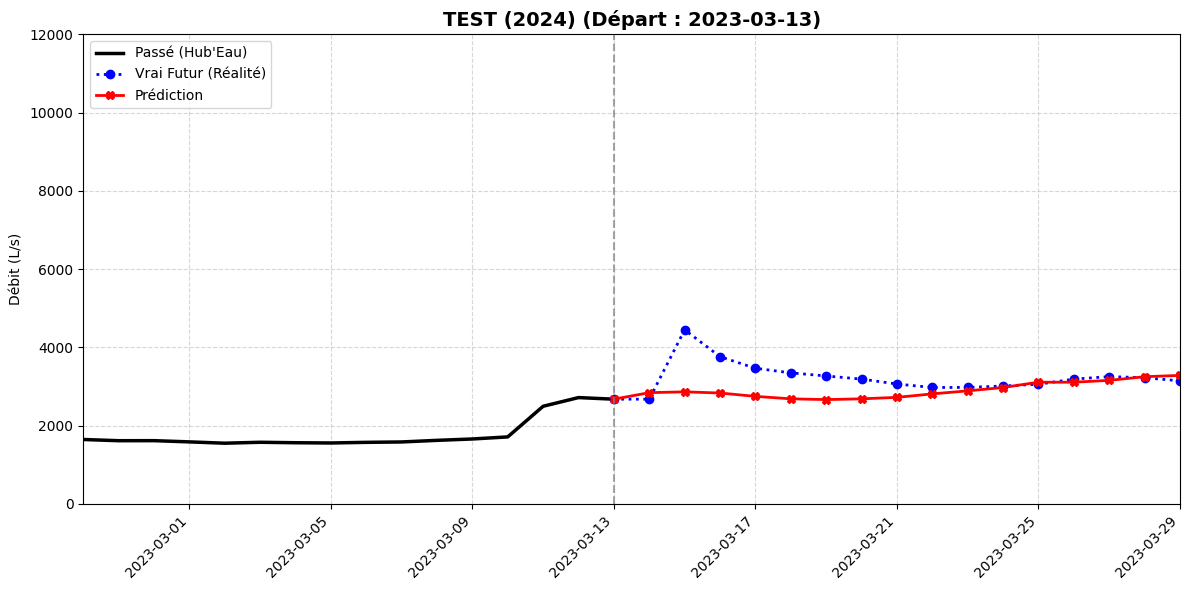

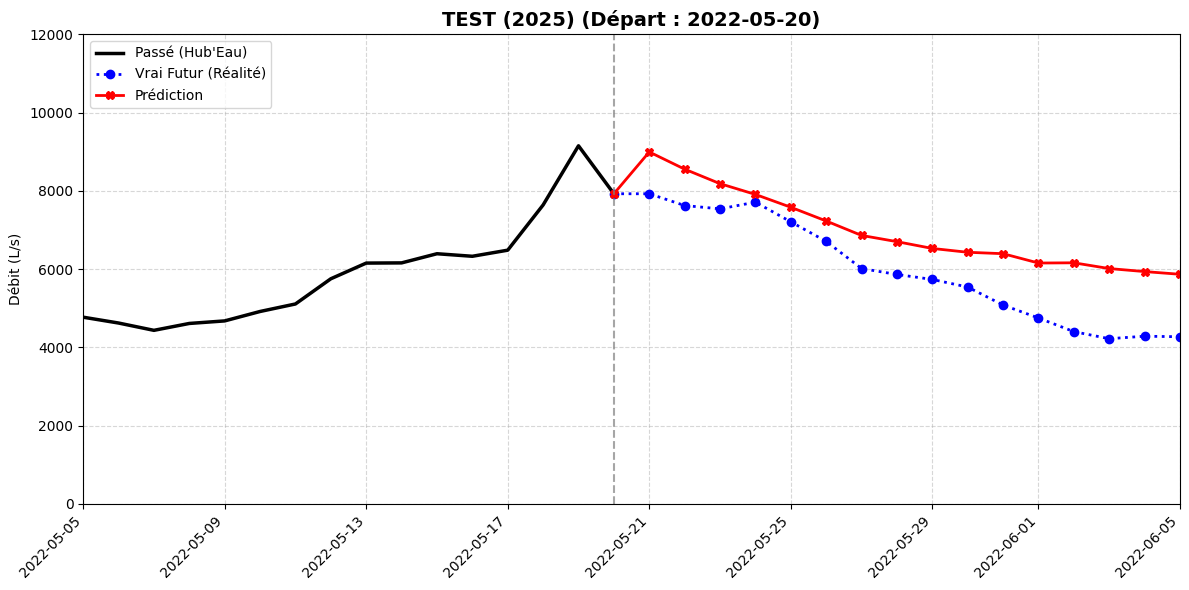

In [469]:
tracer_prediction(df, train, model_nn, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_nn, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_nn, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_nn, features_X, "2022-05-20", "TEST (2025)")

In [497]:
import tensorflow as tf

# Fixer la graine pour la reproductibilité
tf.random.set_seed(42)

# --- LE FIX EST ICI : Conversion des DataFrames Pandas en matrices NumPy ---
X_train_np = X_train[features_X].values.astype(np.float32)
Y_train_np = Y_train[targets_Y].values.astype(np.float32)
X_test_np = X_test[features_X].values.astype(np.float32)
Y_test_np = Y_test[targets_Y].values.astype(np.float32)

# 1. Couche de normalisation intégrée
norm_layer = tf.keras.layers.Normalization(input_shape=(X_train_np.shape[1],))

# 2. Construction du modèle
model_keras = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(150, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(predict_day + 1) # Sortie pour tes 15 jours
])

# 3. Compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_keras.compile(loss="mse", optimizer=optimizer)

# 4. Entraînement de la couche de normalisation sur les données brutes
norm_layer.adapt(X_train_np)

# 5. Entraînement du réseau
print("Début de l'entraînement Keras...")
history = model_keras.fit(X_train_np, Y_train_np, epochs=50, validation_split=0.1, verbose=1)

# 6. Évaluation
print("\nCalcul des prédictions sur le jeu de test...")
predictions_keras = model_keras.predict(X_test_np)

scores_r2_keras = r2_score(Y_test_np, predictions_keras, multioutput='raw_values')

print("\n--- RÉSULTATS TENSORFLOW / KERAS ---")
for i, score in enumerate(scores_r2_keras):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")

Début de l'entraînement Keras...
Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13308890.0000 - val_loss: 5309599.0000
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 4242230.0000 - val_loss: 3783777.5000
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - loss: 3627671.7500 - val_loss: 3373111.0000
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 3343462.0000 - val_loss: 3138560.2500
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - loss: 3149427.2500 - val_loss: 2985235.5000
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 2980917.5000 - val_loss: 2859927.5000
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 2844913.2500 - val_loss: 2741444.5000
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 2724922.7500 - val_loss: 2647193.5000
Epoch 9/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 2604814.7500 - val_loss: 2555353.2500
Epoch 10/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 2485646.0000 - val_loss: 2463972.0000
Epoch 11/50

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


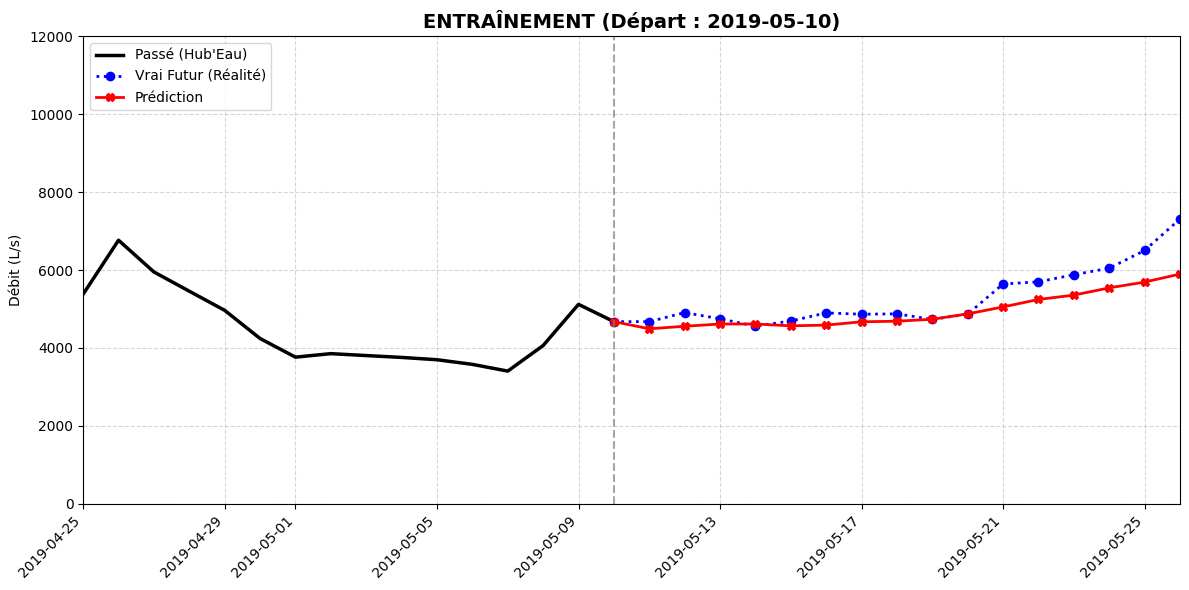

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


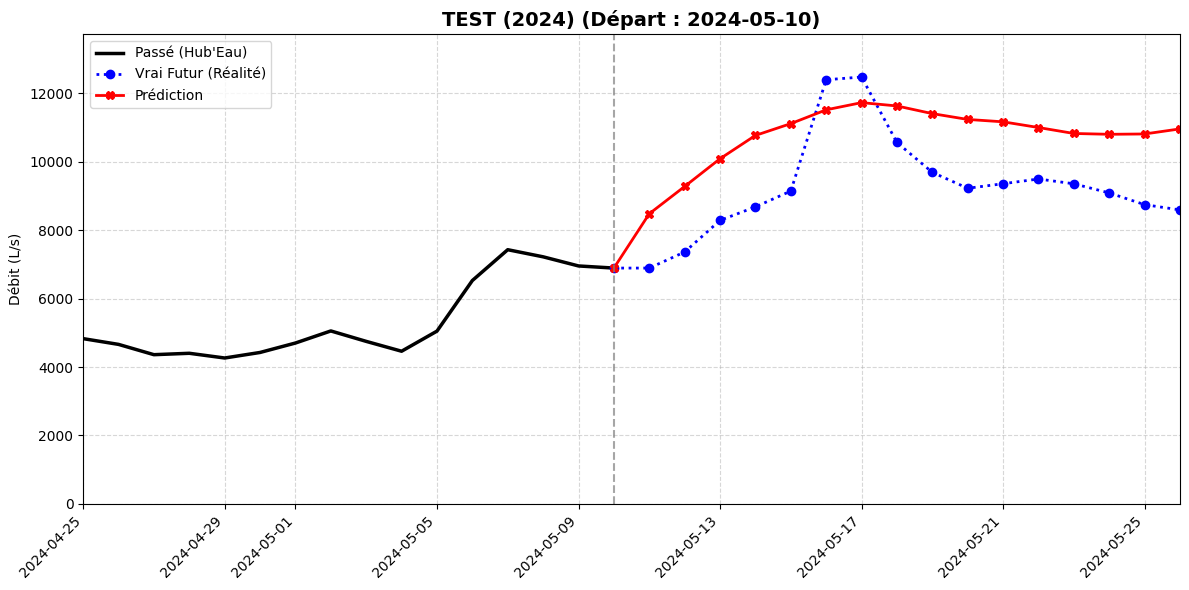

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


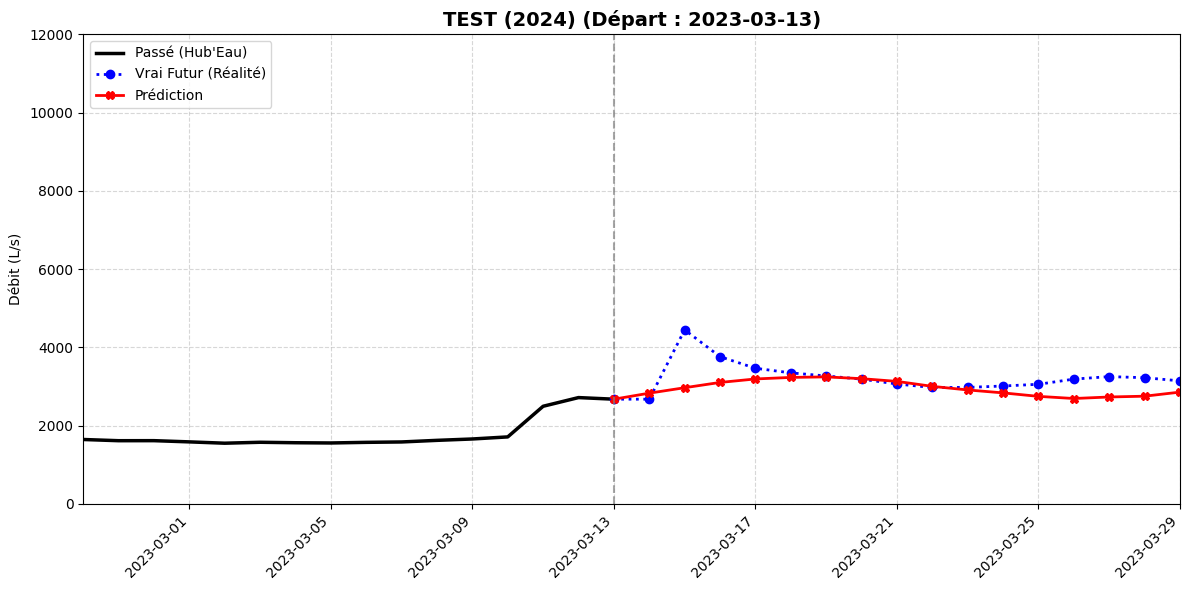

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


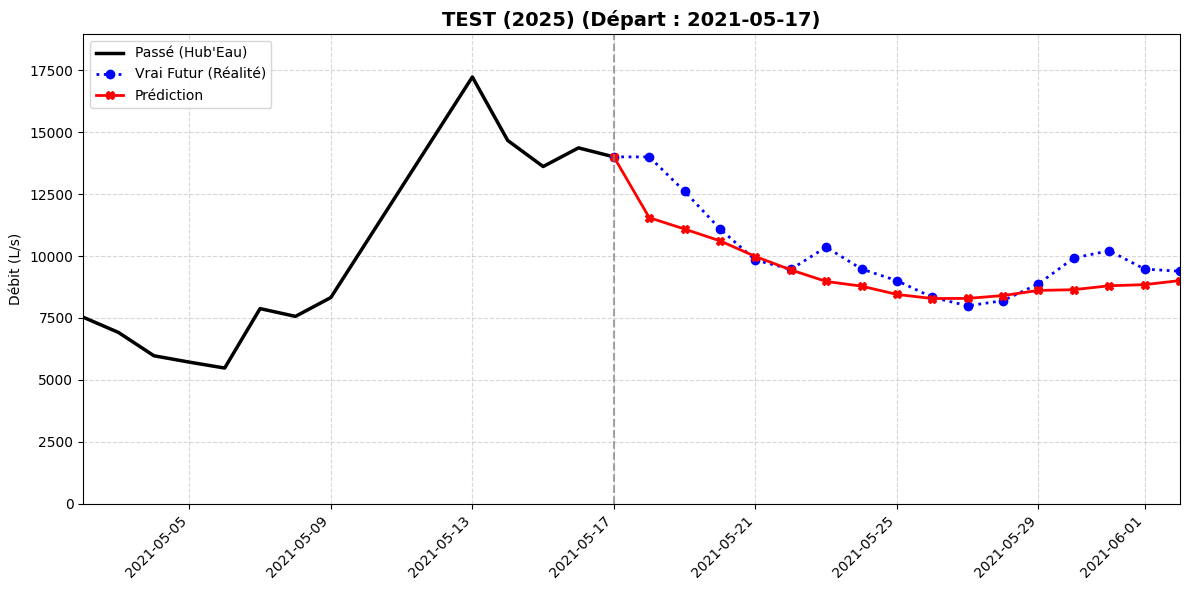

In [501]:
tracer_prediction(df, train, model_keras, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_keras, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_keras, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_keras, features_X, "2021-05-17", "TEST (2025)")

([<matplotlib.axis.XTick at 0x33be80050>,
 [Text(0, 0, 'J+0'),
  Text(1, 0, 'J+1'),
  Text(2, 0, 'J+2'),
  Text(3, 0, 'J+3'),
  Text(4, 0, 'J+4'),
  Text(5, 0, 'J+5'),
  Text(6, 0, 'J+6'),
  Text(7, 0, 'J+7'),
  Text(8, 0, 'J+8'),
  Text(9, 0, 'J+9'),
  Text(10, 0, 'J+10'),
  Text(11, 0, 'J+11'),
  Text(12, 0, 'J+12'),
  Text(13, 0, 'J+13'),
  Text(14, 0, 'J+14'),
  Text(15, 0, 'J+15')])

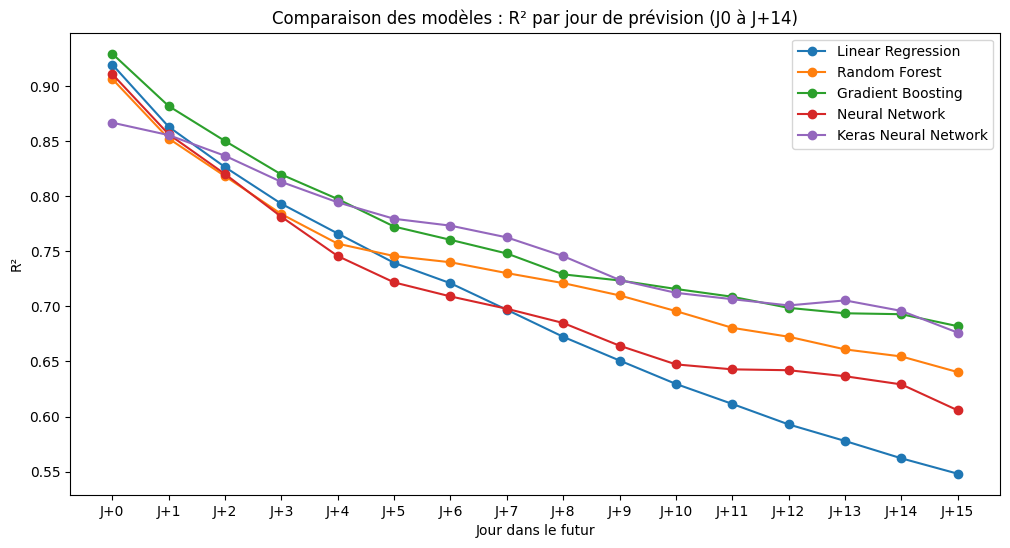

In [498]:
#graph score R2 des modèles
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network', 'Keras Neural Network']
scores = [scores_r2_lin, scores_r2_rf, scores_r2_gb, scores_r2_nn, scores_r2_keras]
plt.figure(figsize=(12, 6))
for i, score in enumerate(scores):
    plt.plot(range(predict_day+1), score, marker='o', label=model_names[i])
plt.title("Comparaison des modèles : R² par jour de prévision (J0 à J+14)")
plt.xlabel("Jour dans le futur")
plt.ylabel("R²")
plt.legend()
plt.xticks(range(predict_day+1), [f"J+{i}" for i in range(predict_day+1)])